In [26]:
from ucimlrepo import fetch_ucirepo
import plotly.express as px
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV
from utils import get_data, get_binary_data, confusion


In [27]:
wine_quality = fetch_ucirepo(name='Wine Quality')
wine_quality_data = wine_quality['data']['original']
seed = 42 

In [28]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed)

In [29]:
penalty = [None, 'l1', 'l2', 'elasticnet']
# no liblinear because it's not multiclass and the data set isn't even small
solvers = ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
cs = [0.001, 0.01, 1, 1.001, 1.01, 1.1, 2, 5, 100]

In [30]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=UserWarning)
    for solv in solvers:
        l1rat = 0
        for pen in penalty:
            match pen:
                case 'elasticnet':
                    l1rat = 0.5
                case 'l1':
                    l1rat = 1
            try:
                max_iters = 0
                max_c = 0
                max_val_accuracy = 0
                max_classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 1, random_state = seed)
                for iters in range(10, 200, 10):
                    for c in cs:
                        classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = iters, C=c, l1_ratio=l1rat, random_state = seed);
                        classifier.fit(wine_X_tr, wine_y_tr);
                        if(100*accuracy_score(wine_y_val, classifier.predict(wine_X_val)) > max_val_accuracy):
                            max_iters = iters
                            max_val_accuracy = 100*accuracy_score(wine_y_val, classifier.predict(wine_X_val))
                            max_classifier = classifier 
                            max_c = c
                print(f'Params: solver: {solv}, penalty: {pen}, C: {max_c}, max_iters: {max_iters}')
                print(f'Training accuracy: {100*accuracy_score(wine_y_tr, max_classifier.predict(wine_X_tr)):.2f}%' )
                print(f'Validation accuracy: {100*accuracy_score(wine_y_val, max_classifier.predict(wine_X_val)):.2f}%\n' )
            except ValueError:
                continue


#Best appears to be saga with penalty l2, max iters 20, C = 0.01. 
#runner ups (by training accuracy) are sag with penalty l2 c 0.01 max_iters 20, and newton-cg with penalty l2 c 0.01 and max iters 10
# also saga with penalty l1, c 1, and max_uters 90 is pretty good


Params: solver: lbfgs, penalty: None, C: 0.001, max_iters: 90
Training accuracy: 54.94%
Validation accuracy: 55.38%

Params: solver: lbfgs, penalty: l2, C: 0.01, max_iters: 10
Training accuracy: 54.14%
Validation accuracy: 56.08%

Params: solver: newton-cg, penalty: None, C: 0.001, max_iters: 20
Training accuracy: 54.89%
Validation accuracy: 55.00%

Params: solver: newton-cg, penalty: l2, C: 0.01, max_iters: 10
Training accuracy: 54.40%
Validation accuracy: 55.62%

Params: solver: newton-cholesky, penalty: None, C: 0.001, max_iters: 10
Training accuracy: 54.89%
Validation accuracy: 55.00%

Params: solver: newton-cholesky, penalty: l2, C: 0.01, max_iters: 10
Training accuracy: 54.40%
Validation accuracy: 55.62%

Params: solver: sag, penalty: None, C: 0.001, max_iters: 20
Training accuracy: 54.58%
Validation accuracy: 55.15%

Params: solver: sag, penalty: l2, C: 0.01, max_iters: 20
Training accuracy: 54.40%
Validation accuracy: 55.62%

Params: solver: saga, penalty: None, C: 0.001, max_i

Sklearn Results:
--- Accuracy (train): 0.544264819091609
--- Accuracy (test): 0.5561538461538461


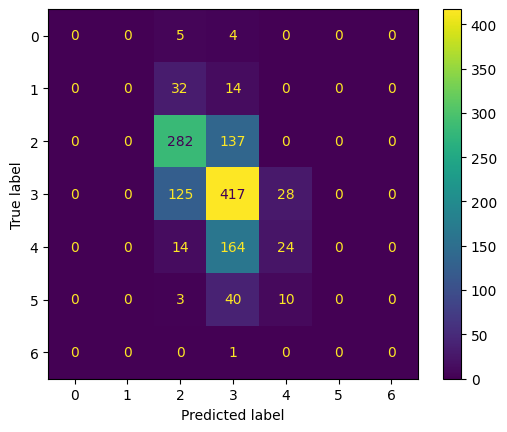

In [31]:
classifier =  LogisticRegression(solver='saga', penalty='l2', max_iter = 20, random_state = seed, C=0.01)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

In [32]:
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_binary_data(seed)

In [33]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=UserWarning)
    for solv in solvers:
        l1rat = 0
        for pen in penalty:
            match pen:
                case 'elasticnet':
                    l1rat = 0.5
                case 'l1':
                    l1rat = 1
            try:
                max_iters = 0
                max_c = 0
                max_val_accuracy = 0
                max_classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = 1, random_state = seed)
                for iters in range(10, 200, 10):
                    for c in cs:
                        classifier = LogisticRegression(solver=solv, penalty=pen, max_iter = iters, C=c, l1_ratio=l1rat, random_state = seed);
                        classifier.fit(wine_X_tr, wine_y_tr);
                        if(100*accuracy_score(wine_y_val, classifier.predict(wine_X_val)) > max_val_accuracy):
                            max_iters = iters
                            max_val_accuracy = 100*accuracy_score(wine_y_val, classifier.predict(wine_X_val))
                            max_classifier = classifier 
                            max_c = c
                print(f'Params: solver: {solv}, penalty: {pen}, C: {max_c}, max_iters: {max_iters}')
                print(f'Training accuracy: {100*accuracy_score(wine_y_tr, max_classifier.predict(wine_X_tr)):.2f}%' )
                print(f'Validation accuracy: {100*accuracy_score(wine_y_val, max_classifier.predict(wine_X_val)):.2f}%\n' )
            except ValueError:
                continue


#Best appears to be saga with penalty l2, max iters 20, C = 0.01. 
#runner ups (by training accuracy) are sag with penalty l2 c 0.01 max_iters 20, and newton-cg with penalty l2 c 0.01 and max iters 10
# also saga with penalty l1, c 1, and max_uters 90 is pretty good


Params: solver: lbfgs, penalty: None, C: 0.001, max_iters: 20
Training accuracy: 73.77%
Validation accuracy: 76.46%

Params: solver: lbfgs, penalty: l2, C: 1, max_iters: 20
Training accuracy: 73.80%
Validation accuracy: 76.46%

Params: solver: newton-cg, penalty: None, C: 0.001, max_iters: 10
Training accuracy: 73.75%
Validation accuracy: 76.38%

Params: solver: newton-cg, penalty: l2, C: 1, max_iters: 10
Training accuracy: 73.77%
Validation accuracy: 76.38%

Params: solver: newton-cholesky, penalty: None, C: 0.001, max_iters: 10
Training accuracy: 73.75%
Validation accuracy: 76.46%

Params: solver: newton-cholesky, penalty: l2, C: 1, max_iters: 10
Training accuracy: 73.77%
Validation accuracy: 76.38%

Params: solver: sag, penalty: None, C: 0.001, max_iters: 20
Training accuracy: 73.75%
Validation accuracy: 76.38%

Params: solver: sag, penalty: l2, C: 1, max_iters: 20
Training accuracy: 73.77%
Validation accuracy: 76.38%

Params: solver: saga, penalty: None, C: 0.001, max_iters: 20
Tra

Sklearn Results:
--- Accuracy (train): 0.7367205542725174
--- Accuracy (test): 0.7607692307692308


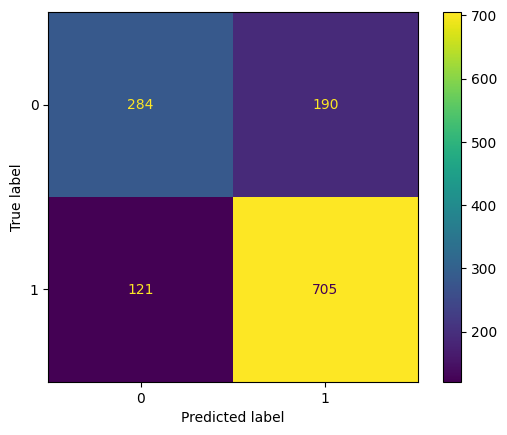

In [35]:
classifier =  LogisticRegression(solver='saga', penalty='l2', max_iter = 20, random_state = seed, C=0.01)
confusion(classifier, wine_X_tr, wine_y_tr, wine_X_val, wine_y_val)

In [34]:
# # Create a figure with only one subplot
# figure, axes = plt.subplots(1, figsize=(6, 6))

# ### YOUR CODE STARTS HERE ###

# errors_tr = []
# errors_te = []

# k = [1, 2, 5, 10, 50, 100, 110]
# for i in range(len(k)):
#     knn_classifier = KNeighborsClassifier(n_neighbors=k[i])
#     knn_classifier.fit(peng_X_tr, peng_y_tr)
#     y_pred = knn_classifier.predict(peng_X_tr)
#     accuracy = accuracy_score(peng_y_tr, y_pred)
#     errors_tr.append(1-accuracy)
#     y_pred = knn_classifier.predict(peng_X_te)
#     accuracy = accuracy_score(peng_y_te, y_pred)
#     errors_te.append(1-accuracy)

# axes.semilogx(k, errors_tr, c='r', label = "training")
# axes.semilogx(k, errors_te, c = 'g', label = "testing")
# axes.set_xlabel('k')
# axes.set_ylabel('error')
# axes.legend()

# ### YOUR CODE ENDS HERE ###